# Sentiment Analysis with Bag of Words and TF-IDF using ML Algorithm

## Purpose
This notebook demonstrates a sentiment analysis task using a dataset of movie reviews. It covers data loading, text preprocessing (cleaning, stop word removal, lemmatization), feature extraction using Bag of Words (CountVectorizer) and TF-IDF (TfidfVectorizer), and finally, training and evaluating a RandomForestClassifier for sentiment prediction.

In [ ]:
import kagglehub
rajathmc_bag_of_words_meets_bags_of_popcorn__path = kagglehub.dataset_download('rajathmc/bag-of-words-meets-bags-of-popcorn-')
aayushkubba_mask_image_path = kagglehub.dataset_download('aayushkubba/mask-image')

print('Data source import complete.')

100%|██████████| 52.4M/52.4M [00:00<00:00, 76.5MB/s]

Extracting files...


100%|██████████| 327k/327k [00:00<00:00, 23.8MB/s]

Extracting files...
Data source import complete.


## 1. Data Loading and Initial Exploration

This section focuses on loading the IMDB movie review dataset and performing initial checks to understand its structure and content.

In [ ]:
!ls /root/.cache/kagglehub/datasets/rajathmc/bag-of-words-meets-bags-of-popcorn-/versions/1/

labeledTrainData.tsv  testData.tsv
sampleSubmission.csv  unlabeledTrainData.tsv


In [ ]:
rajathmc_bag_of_words_meets_bags_of_popcorn__path

'/root/.cache/kagglehub/datasets/rajathmc/bag-of-words-meets-bags-of-popcorn-/versions/1'

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
for dirname, _, filenames in os.walk('/root/.cache/kagglehub/datasets/rajathmc/bag-of-words-meets-bags-of-popcorn-/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/root/.cache/kagglehub/datasets/rajathmc/bag-of-words-meets-bags-of-popcorn-/1.complete
/root/.cache/kagglehub/datasets/rajathmc/bag-of-words-meets-bags-of-popcorn-/versions/1/testData.tsv
/root/.cache/kagglehub/datasets/rajathmc/bag-of-words-meets-bags-of-popcorn-/versions/1/labeledTrainData.tsv
/root/.cache/kagglehub/datasets/rajathmc/bag-of-words-meets-bags-of-popcorn-/versions/1/unlabeledTrainData.tsv
/root/.cache/kagglehub/datasets/rajathmc/bag-of-words-meets-bags-of-popcorn-/versions/1/sampleSubmission.csv


### Load Dataset
We'll load the `labeledTrainData.tsv` file into a pandas DataFrame. This file contains movie reviews with sentiment labels.

In [ ]:
train = pd.read_csv("/root/.cache/kagglehub/datasets/rajathmc/bag-of-words-meets-bags-of-popcorn-/versions/1/labeledTrainData.tsv",delimiter="\t")

In [ ]:
train.head()

,id,sentiment,review
0,5814_8,1,With all this stuff going down at the moment w...
1,2381_9,1,"\The Classic War of the Worlds\"" by Timothy Hi..."
2,7759_3,0,The film starts with a manager (Nicholas Bell)...
3,3630_4,0,It must be assumed that those who praised this...
4,9495_8,1,Superbly trashy and wondrously unpretentious 8...


### Sample Review

Let's inspect a sample review to understand the raw text format before preprocessing.

In [ ]:
train['review'][29]

"Would anyone really watch this RUBBISH if it didn't contain little children running around nude? From a cinematic point of view it is probably one of the worst films I have encountered absolutely dire. Some perv woke up one day and thought I will make a film with little girls in and call it art, stick them in countryside and there isn't any need for a story or explanation of how they got there or why they don't appear to live anywhere or have parents because p*rn films don't need anything like that. I would comment on the rest of the film but I haven't ticked spoilers so I will just say avoid, avoid avoid and find yourself a proper film to watch"

##  Text Preprocessing

Raw text data often contains noise that needs to be cleaned before it can be used for machine learning. This section outlines the preprocessing steps applied to the movie reviews.

In [ ]:
!pip install nltk
!pip install beautifulsoup4

### Importing Libraries and Downloading NLTK Data

We'll use `nltk` for natural language processing tasks like stopword removal and lemmatization, and `BeautifulSoup` for HTML tag removal. First, we need to install and import these libraries, and download necessary NLTK data.

In [ ]:
import re
import nltk
from bs4 import BeautifulSoup

In [ ]:
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

True

### Initializing Stopwords and Lemmatizer

We initialize the English stopwords list from NLTK and a WordNet Lemmatizer to reduce words to their base forms.

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
stopwords = stopwords.words("english")
wordnet_lemma = WordNetLemmatizer()

### Preprocessing Function

The `preprocess_text` function performs the following steps:

1.  **Remove HTML tags:** Uses `BeautifulSoup` to strip out any HTML tags present in the review.
2.  **Remove non-alphabetic characters:** Keeps only letters, replacing other characters (numbers, punctuation) with spaces.
3.  **Lowercase conversion:** Converts all text to lowercase to ensure consistency.
4.  **Stopword removal:** Removes common words (like 'a', 'the', 'is') that do not carry much sentiment information.
5.  **Lemmatization:** Reduces words to their base or root form (e.g., 'running' to 'run', 'better' to 'good').

In [ ]:
review = train['review'][0]

In [ ]:
review

"With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent. Moonwalker is part biography, part feature film which i remember going to see at the cinema when it was originally released. Some of it has subtle messages about MJ's feeling towards the press and also the obvious message of drugs are bad m'kay.<br /><br />Visually impressive but of course this is all about Michael Jackson so unless you remotely like MJ in anyway then you are going to hate this and find it boring. Some may call MJ an egotist for consenting to the making of this movie BUT MJ and most of his fans would say that he made it for the fans which if true is really nice of him.<br /><br />The actual feature film bit when it finally sta

In [ ]:
def preprocess_text(review):
  #remove all HTML tages
  review = BeautifulSoup(review).get_text()

  #Lowercase
  review = review.lower()

  #stopword
  review = " ".join([i for i in review.split() if i not in stopwords])

  #lematizer
  review = " ".join([wordnet_lemma.lemmatize(i) for i in review.split() ])

  return review

### Preprocessing Demonstration

Let's see how the `preprocess_text` function transforms a sample review.

In [ ]:
review = review =train['review'][0]
print("Original Text: ")
print(review)
print("-"*25)
cleaned_review = preprocess_text(review)
print("Cleaned Text: ")
print(cleaned_review)

Original Text: 
With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent. Moonwalker is part biography, part feature film which i remember going to see at the cinema when it was originally released. Some of it has subtle messages about MJ's feeling towards the press and also the obvious message of drugs are bad m'kay.<br /><br />Visually impressive but of course this is all about Michael Jackson so unless you remotely like MJ in anyway then you are going to hate this and find it boring. Some may call MJ an egotist for consenting to the making of this movie BUT MJ and most of his fans would say that he made it for the fans which if true is really nice of him.<br /><br />The actual feature film bit when

### Apply Preprocessing
We apply the `preprocess_text` function to the 'review' column of our training data and store the cleaned reviews in a new column called 'clean_review'.

In [ ]:
train['clean_review'] = train['review'].apply(preprocess_text)

## Exploratory Data Analysis (EDA) on Cleaned Text
Here, we explore the word frequencies in the cleaned text, looking at overall most frequent words, and then specifically for positive and negative reviews. A word cloud is also generated to visualize common words.

In [ ]:
#Give me list of all words frequency
train.head()

,id,sentiment,review,clean_review
0,5814_8,1,With all this stuff going down at the moment w...,"stuff going moment mj started listening music,..."
1,2381_9,1,"\The Classic War of the Worlds\"" by Timothy Hi...","\the classic war worlds\"" timothy hines entert..."
2,7759_3,0,The film starts with a manager (Nicholas Bell)...,film start manager (nicholas bell) giving welc...
3,3630_4,0,It must be assumed that those who praised this...,must assumed praised film (\the greatest filme...
4,9495_8,1,Superbly trashy and wondrously unpretentious 8...,superbly trashy wondrously unpretentious 80's ...


### Word Frequency Analysis

We will calculate the frequency of each word in the entire corpus and identify the most common words.

In [ ]:
freq_list = {}
for review in train['clean_review'].tolist():
  for word in review.split():
    freq_list[word] = freq_list.get(word,0)+1

In [ ]:
#Give 10 most frequent words
sorted_freq_words = dict(sorted(freq_list.items(),key = lambda item:item[1],reverse = True))

### Most Frequent Words (Overall)
We use `collections.Counter` to find the most common words across all cleaned reviews.

In [ ]:
from collections import Counter
cnt = Counter(" ".join(train['clean_review'].tolist()).split())

In [ ]:
#Most frequent words in positive and negative reviews.
pos_cnt = Counter(" ".join(train[train['sentiment']==1]['clean_review'].tolist()).split())
neg_cnt = Counter(" ".join(train[train['sentiment']==0]['clean_review'].tolist()).split())

### Most Frequent Words in Positive and Negative Reviews
Understanding which words are prevalent in positive versus negative reviews can provide insights into sentiment indicators.

In [ ]:
pos_cnt.most_common(10)

[('film', 17321),
 ('movie', 16028),
 ('one', 12011),
 ('like', 8554),
 ('good', 6102),
 ('see', 5741),
 ('get', 5564),
 ('story', 5532),
 ('great', 5514),
 ('make', 5499)]

In [ ]:
neg_cnt.most_common(10)

[('movie', 20108),
 ('film', 15279),
 ('one', 11137),
 ('like', 10679),
 ('even', 7365),
 ('would', 6787),
 ('get', 6515),
 ('make', 6242),
 ('good', 5853),
 ('really', 5806)]

### Word Cloud Visualization

A word cloud visually represents word frequencies, where larger words appear more frequently. We'll generate a word cloud for all cleaned reviews, excluding 'film' and 'movie' as they are very common but not necessarily sentiment-indicative.

In [ ]:
from wordcloud import WordCloud

In [ ]:
wordcloud = WordCloud(stopwords = ["film","movie"],
                      width = 800,
                      height = 400,
                      background_color = "white").generate(" ".join(train['clean_review'].tolist()))

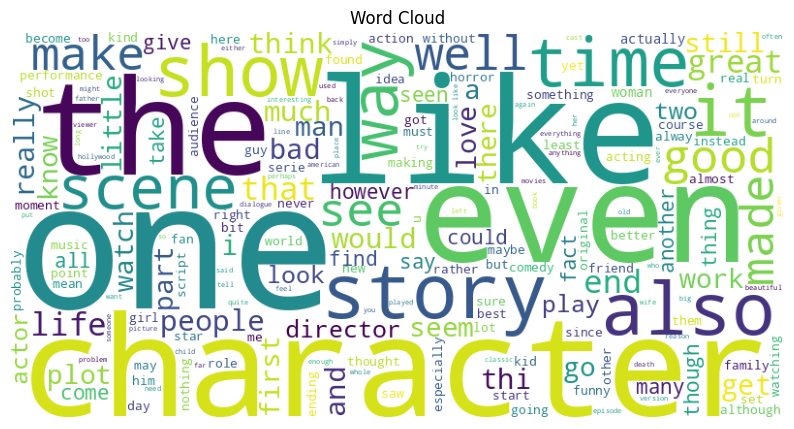

In [ ]:
plt.figure(figsize=(10,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Word Cloud")
plt.show()

## Feature Extraction and Model Training
This section involves converting the cleaned text data into numerical features that can be used by machine learning models. We will explore two common methods: CountVectorizer (Bag of Words) and TfidfVectorizer. After feature extraction, a RandomForestClassifier will be trained and evaluated.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
train.columns

Index(['id', 'sentiment', 'review', 'clean_review'], dtype='object')

In [ ]:
x = train['clean_review']
y = train['sentiment']

### Split Data into Training and Testing Sets
We split the dataset into training and testing sets to evaluate the model's performance on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 1)

In [ ]:
def create_vector(vectorizer,data):
  train_vector = vectorizer.transform(data.tolist())
  return train_vector.toarray()

### CountVectorizer (Bag of Words)
Bag of Words (BoW) represents text data as a bag (multiset) of words, disregarding grammar and even word order but keeping multiplicity. We use `CountVectorizer` to transform the text into a matrix of token counts.

In [ ]:
len(cnt)

265387

In [ ]:
vectorizer = CountVectorizer(max_features=15000)


In [ ]:
vectorizer.fit(x_train.tolist())

CountVectorizer(max_features=15000)

### Train and Evaluate RandomForest with CountVectorizer
Now, we train a RandomForestClassifier using the features generated by the CountVectorizer and evaluate its performance.

In [ ]:
x_train_vector = create_vector(vectorizer,x_train)
x_test_vector = create_vector(vectorizer,x_test)

In [ ]:
x_train_vector.shape

(20000, 15000)

In [ ]:
x_train_vector[100]

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rt = RandomForestClassifier(n_estimators = 100)

In [ ]:
rt.fit(x_train_vector,y_train)

RandomForestClassifier()

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
y_pred=rt.predict(x_test_vector)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85      2503
           1       0.86      0.84      0.85      2497

    accuracy                           0.85      5000
   macro avg       0.85      0.85      0.85      5000
weighted avg       0.85      0.85      0.85      5000



### TF-IDF Vectorizer
TF-IDF (Term Frequency-Inverse Document Frequency) is another method that reflects how important a word is to a document in a collection or corpus. It increases proportionally to the number of times a word appears in the document but is offset by the frequency of the word in the corpus, which helps to adjust for the fact that some words appear more frequently in general.

In [ ]:
len(vectorizer.vocabulary_)

15000

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tf_vectorizer = TfidfVectorizer(analyzer="word",
                                tokenizer=nltk.word_tokenize,
                                preprocessor = None,
                                stop_words = 'english',
                                max_features=10000)

In [ ]:
tf_vectorizer.fit(x_train.tolist())

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


TfidfVectorizer(max_features=10000, stop_words='english',
                tokenizer=<function word_tokenize at 0x7a9b3f76be20>)

In [ ]:
x_train_tfvector = create_vector(tf_vectorizer,x_train)
x_test_tfvector = create_vector(tf_vectorizer,x_test)

### Train and Evaluate RandomForest with TF-IDF Vectorizer
Finally, we train another RandomForestClassifier using the TF-IDF features and compare its performance.

In [ ]:
forest=RandomForestClassifier(n_estimators = 100)
forest.fit(x_train_tfvector,y_train)

RandomForestClassifier()

In [ ]:
y_pred=forest.predict(x_test_tfvector)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84      2503
           1       0.85      0.83      0.84      2497

    accuracy                           0.84      5000
   macro avg       0.84      0.84      0.84      5000
weighted avg       0.84      0.84      0.84      5000



## Conclusion
This notebook demonstrates two common feature extraction techniques (Bag of Words and TF-IDF) for text data in a sentiment analysis task. Both methods, when combined with a RandomForestClassifier, yielded similar and reasonably good performance, indicating their effectiveness in capturing sentiment from movie reviews.